# Q1 Visualizations
Author: Gia Bao (Belinda) Ngo

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the merged & cleaned Applicant dataset

In [11]:
file_path = "../data/40B_zip_long_lat.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_").str.replace("?", "")
print(len(df))
df = df[
    (df['current_residence_town_city'] != 'Unknown') &
    (df['current_residence_state'] != 'Unknown') &
    (df['age'] != 0) &
    (~df['hh_size'].isin([0, 20, 31]))
]
print(len(df))
df.head()

1465
1456


,id_number,submission_date,age,disability,chapa_races,census_races,current_residence_town_city,current_residence_state,current_residence_zip,application_source,...,property_lon,current_lat,current_lon,distance_km,distance_mi,current_county,property_county,local_applicant_county,local_applicant_town,local_applicant_distance
0,150733,2022-02-08,65,0,White/Non-Minority,White alone,Somerville,MA,2145,Unknown,...,-71.11,42.39,-71.10,34.445797,21.403626,Middlesex,Essex,0.0,0.0,0.0
1,439181,2022-02-08,59,0,Hispanic/Latino,Unknown,Westford,MA,1886,Unknown,...,-71.11,42.58,-71.43,29.436218,18.290818,Middlesex,Essex,0.0,0.0,0.0
2,226436,2022-02-08,60,0,White/Non-Minority,White alone,Nashua,NH,3060,Unknown,...,-71.11,42.74,-71.45,28.201723,17.523738,NaN,Essex,0.0,0.0,0.0
3,170029,2021-06-15,35,0,White/Non-Minority,White alone,Waltham,MA,2453,Unknown,...,-71.26,42.37,-71.24,12.329329,7.661090,Middlesex,Middlesex,1.0,0.0,0.0
4,569863,2021-06-15,38,0,Black or African American,Black or African American alone,Woburn,MA,1801,Unknown,...,-71.26,42.48,-71.15,9.044772,5.620161,Norfolk,Middlesex,0.0,0.0,0.0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1456 entries, 0 to 1464
Data columns (total 51 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   id_number                                 1456 non-null   int64  
 1   submission_date                           1456 non-null   object 
 2   age                                       1456 non-null   int64  
 3   disability                                1456 non-null   int64  
 4   chapa_races                               1456 non-null   object 
 5   census_races                              1456 non-null   object 
 6   current_residence_town_city               1456 non-null   object 
 7   current_residence_state                   1456 non-null   object 
 8   current_residence_zip                     1456 non-null   int64  
 9   application_source                        1456 non-null   object 
 10  hh_size                                  

### Question 1a: How far from their current homes, do applicants apply for these affordable homeownership opportunities?

#### Proportion of Unique Applicants by Current Residence State (Excluding MA and Unknown)

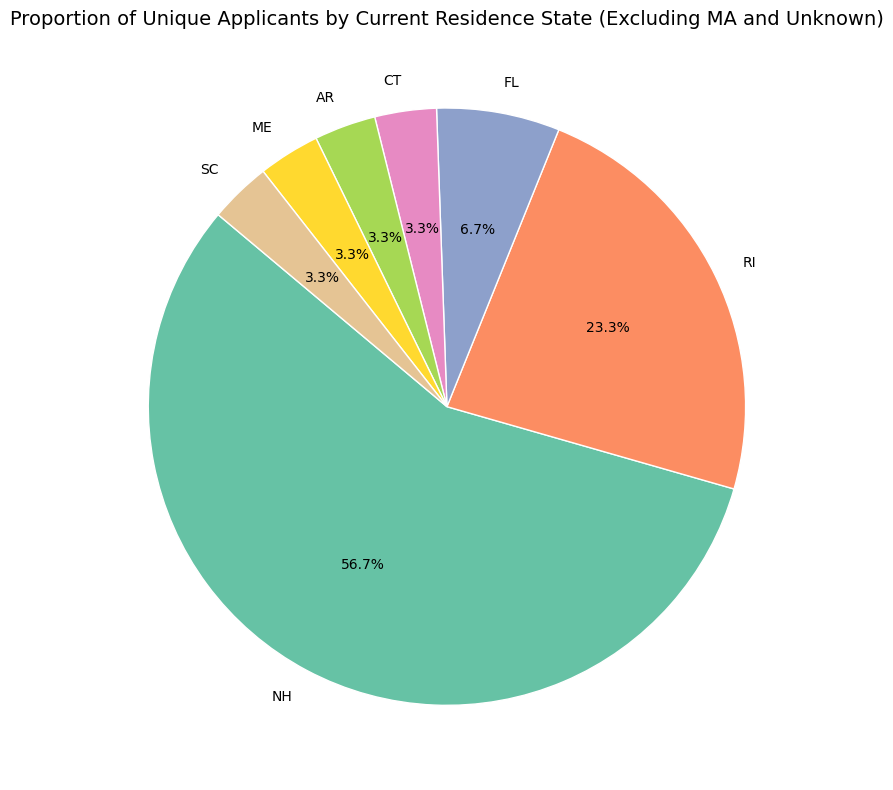

In [10]:
# Filter out MA and Unknown
df_no_ma = df[(df['current_residence_state'] != 'MA') & 
               (df['current_residence_state'] != 'Unknown')]

# Count unique applicants per state
unique_applicants = df_no_ma.groupby('current_residence_state')['id_number'].nunique()
unique_applicants = unique_applicants.sort_values(ascending=False)

# Choose a prettier color palette from seaborn
colors = sns.color_palette("Set2", n_colors=len(unique_applicants))

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(
    unique_applicants,
    labels=unique_applicants.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}  # adds separation between slices
)
plt.title("Proportion of Unique Applicants by Current Residence State (Excluding MA and Unknown)", fontsize=14)
plt.tight_layout()
plt.show()

### Question 1b: How does the applicant geographic range compare between different demographic groups? (e.g., race, household type, age, marketing source, etc.). Are local applicant demographics similar or different from more distant applicants?